In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

## Study count visual

In [3]:
df = pd.read_csv('data/partitions/wos_all.csv')

/var/folders/sf/ksfgwr354pl2gjdb_f0yn3vr0000gn/T/ipykernel_89306/2442605203.py:1: DtypeWarning: Columns (13,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/partitions/wos_all.csv')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2337371 entries, 0 to 2337370
Data columns (total 29 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Publication Type          object 
 1   Authors                   object 
 2   Article Title             object 
 3   Language                  object 
 4   Document Type             object 
 5   Author Keywords           object 
 6   Keywords Plus             object 
 7   Abstract                  object 
 8   ORCIDs                    object 
 9   Funding Orgs              object 
 10  Publisher                 object 
 11  ISSN                      object 
 12  eISSN                     object 
 13  ISBN                      object 
 14  Journal Abbreviation      object 
 15  Journal ISO Abbreviation  object 
 16  Publication Date          object 
 17  Publication Year          int64  
 18  Volume                    object 
 19  Issue                     object 
 20  Part Number             

In [9]:
summary = df.groupby('Publication Year')['UT (Unique WOS ID)'].nunique().rename('count').to_frame()
summary = summary.drop(2026, errors='ignore')
summary['count-screened'] = (summary['count'] * 0.12).round().astype(int)
print(summary.to_string())
print(f"\nTotal: {summary['count'].sum()} | Screened: {summary['count-screened'].sum()}")

                   count  count-screened
Publication Year                        
2000               23436            2812
2001               25524            3063
2002               26821            3219
2003               29249            3510
2004               31057            3727
2005               34031            4084
2006               38291            4595
2007               42273            5073
2008               46685            5602
2009               51384            6166
2010               55640            6677
2011               62212            7465
2012               66670            8000
2013               77328            9279
2014               83326            9999
2015               91376           10965
2016              102451           12294
2017              108002           12960
2018              117498           14100
2019              133391           16007
2020              151121           18135
2021              169384           20326
2022            

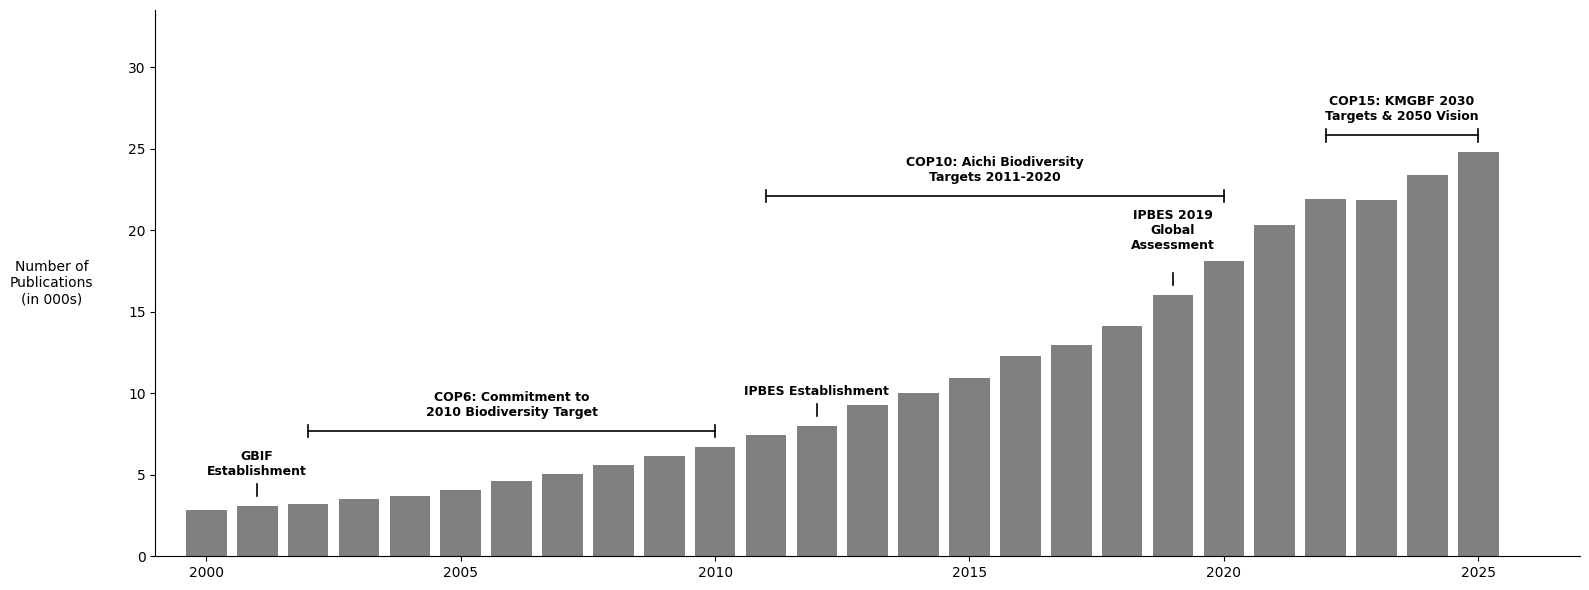

In [47]:
# --- Define groups here ---
# Each group: (label, start_year, end_year, y_offset)
# y_offset controls vertical stacking: 0 = near bar top, 1 = one level up, etc.
# For a single-year marker, use the same year for start and end
groups = [
    ('GBIF\nEstablishment', 2001, 2001, 0),
    ('COP6: Commitment to\n2010 Biodiversity Target', 2002, 2010, 0),
    ('IPBES Establishment', 2012, 2012, 0),
    ('COP10: Aichi Biodiversity\nTargets 2011-2020', 2011, 2020, 1),
    ('IPBES 2019\nGlobal\nAssessment\n', 2019, 2019, 0),
    ('COP15: KMGBF 2030\nTargets & 2050 Vision', 2022, 2025, 0),
]

def plot_study_count(ax):
    """Plot the study count bar chart with group annotations onto a given axes."""
    years = summary.index.values
    counts = summary['count-screened'].values / 1000

    ax.bar(years, counts, color='grey', edgecolor='none')

    ax.set_ylabel('Number of\nPublications\n(in 000s)', rotation=0, labelpad=55, va='center')
    ax.spines[['top', 'right']].set_visible(False)

    bar_max = counts.max()
    tick_h = bar_max * 0.015
    level_step = bar_max * 0.12

    for label, y_start, y_end, y_off in groups:
        mask = (years >= y_start) & (years <= y_end)
        group_max = counts[mask].max()
        y_level = group_max + bar_max * 0.04 + y_off * level_step

        if y_start == y_end:
            ax.plot([y_start, y_start], [y_level - tick_h, y_level + tick_h], color='black', lw=1.2, clip_on=False)
        else:
            ax.plot([y_start, y_end], [y_level, y_level], color='black', lw=1.2, clip_on=False)
            ax.plot([y_start, y_start], [y_level - tick_h, y_level + tick_h], color='black', lw=1.2, clip_on=False)
            ax.plot([y_end, y_end], [y_level - tick_h, y_level + tick_h], color='black', lw=1.2, clip_on=False)

        mid = (y_start + y_end) / 2
        ax.text(mid, y_level + tick_h * 2, label,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlim(years.min() - 1, years.max() + 2)
    ax.set_ylim(0, bar_max * 1.35)

# --- Standalone preview ---
fig_study, ax_study = plt.subplots(figsize=(16, 6))
plot_study_count(ax_study)
plt.tight_layout()
plt.show()

## Driver Distribution Visual

In [43]:
import ast
import numpy as np

# --- Load and merge to get Publication Year ---
driver_df = pd.read_excel('data/labels/eval/sampled_records_driver/data/driver.xlsx')
# pd.read_excel('data/labels/eval/l1-0502-test/data/driver.xlsx')


sampled_df = pd.read_excel('data/sampled/wos_sampled_200_per_year.xlsx')

driver_df = driver_df.merge(
    sampled_df[['UT (Unique WOS ID)', 'Publication Year']],
    left_on='custom_id', right_on='UT (Unique WOS ID)', how='left'
)
driver_df = driver_df[driver_df['Publication Year'] != 2026]

# --- Explode multi-label driver_pred_norm into one row per driver ---
# e.g. "['climate change', 'pollution']" -> two rows
driver_df['drivers_list'] = driver_df['driver_pred_norm'].apply(ast.literal_eval)
exploded = driver_df.explode('drivers_list')

# --- Build year x driver counts ---
DRIVERS = [
    'climate change',
    'land/sea use change',
    'direct exploitation and resource extraction',
    'pollution',
    'invasive alien species',
]

ct = exploded.groupby(['Publication Year', 'drivers_list']).size().unstack(fill_value=0)
ct = ct.reindex(columns=DRIVERS, fill_value=0)
ct = ct.loc[ct.index.isin(range(2000, 2026))]  # 2000-2025

# Convert to percentages (each year sums to 100% of total driver mentions)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

print(f"Total records: {len(driver_df)}")
print(f"Total driver mentions after explode: {len(exploded)}")
print(f"Avg mentions per record: {len(exploded)/len(driver_df):.2f}")
print()
print(pct.round(1))

Total records: 5200
Total driver mentions after explode: 8021
Avg mentions per record: 1.54

drivers_list      climate change  land/sea use change  \
Publication Year                                        
2000                        21.4                 21.7   
2001                        19.9                 22.7   
2002                        16.7                 23.9   
2003                        18.6                 26.2   
2004                        19.8                 23.5   
2005                        18.1                 26.0   
2006                        19.3                 23.3   
2007                        20.5                 25.2   
2008                        22.1                 23.8   
2009                        17.3                 23.5   
2010                        19.8                 25.5   
2011                        19.4                 24.3   
2012                        24.3                 23.6   
2013                        25.3                 22.

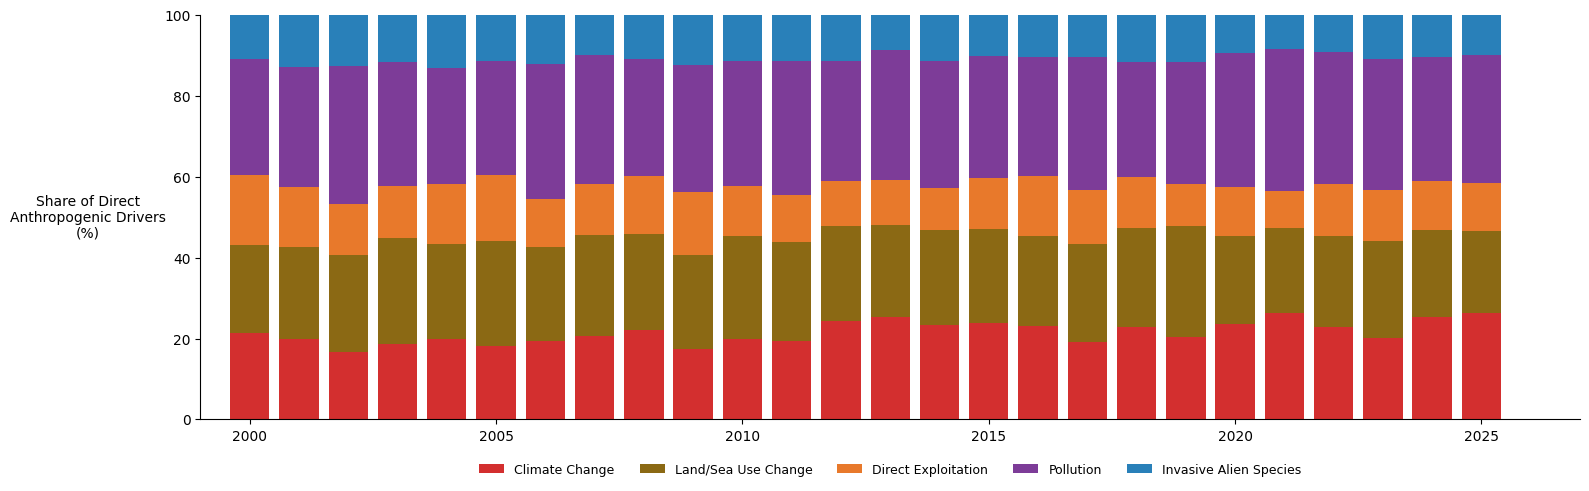

In [50]:
# --- Colors chosen to evoke each driver thematically ---
DRIVER_COLORS = {
    'climate change':                            '#D32F2F',  
    'land/sea use change':                       '#8B6914', 
    'direct exploitation and resource extraction':'#E8792B',  
    'pollution':                                 '#7D3C98',  
    'invasive alien species':                    '#2980B9', 
}

DRIVER_LABELS = {
    'climate change':                            'Climate Change',
    'land/sea use change':                       'Land/Sea Use Change',
    'direct exploitation and resource extraction':'Direct Exploitation',
    'pollution':                                 'Pollution',
    'invasive alien species':                    'Invasive Alien Species',
}

def plot_driver_distribution(ax):
    """Plot stacked % bar chart of driver mentions per year."""
    years = pct.index.values
    bottom = np.zeros(len(years))

    for driver in DRIVERS:
        vals = pct[driver].values
        ax.bar(years, vals, bottom=bottom, width=0.8,
               color=DRIVER_COLORS[driver], edgecolor='none',
               label=DRIVER_LABELS[driver])
        bottom += vals

    ax.set_ylabel('Share of Direct\nAnthropogenic Drivers\n(%)', rotation=0, labelpad=55, va='center')
    ax.set_ylim(0, 100)
    ax.set_xlim(years.min() - 1, years.max() + 2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
              ncol=5, frameon=False, fontsize=9)

# --- Standalone preview (same width as study count) ---
fig_drv, ax_drv = plt.subplots(figsize=(16, 5))
plot_driver_distribution(ax_drv)
plt.tight_layout()
plt.show()